# CIFAR-10 CNN: TensorFlow vs PyTorch

Practice activity from Microsoft *Foundations of AI and Machine Learning* - Module: Frameworks and Tools.

Same 2-conv-layer CNN implemented in both `tf.keras` and PyTorch, trained for 10 epochs on CIFAR-10. The point isn't to win at CIFAR-10 - this small architecture caps out around 65-70% test accuracy - but to feel the API differences directly.

Training takes ~10-20 minutes per framework on CPU, so this notebook shows the architectures and reads the results from `histories.npz` produced by [`cifar10_tf_vs_pytorch.py`](cifar10_tf_vs_pytorch.py). To regenerate the numbers, run that script.

## 1. Imports

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
import torch
import torch.nn as nn
import torch.nn.functional as F
print(f'TF {tf.__version__} | PyTorch {torch.__version__}')

TF 2.21.0 | PyTorch 2.12.0+cpu


## 2. The TensorFlow / Keras model

`Sequential` chain. Input shape is declared up front, every layer passes a fully-shaped tensor to the next. Compile binds the optimizer, loss, and metric; `.fit()` handles the entire training loop, batching, validation, and logging.

In [2]:
tf_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax'),
])
tf_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
tf_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

## 3. The PyTorch model

Subclass `nn.Module`, declare submodules in `__init__`, write the forward pass yourself. Shape math (`64 * 6 * 6`) is your responsibility. There is no compile step - you build the optimizer and loss separately and run the training loop by hand.

In [3]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,  32, 3)
        self.pool  = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.fc1   = nn.Linear(64 * 6 * 6, 64)
        self.fc2   = nn.Linear(64, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

pt_model = SimpleCNN()
print(pt_model)
n_params = sum(p.numel() for p in pt_model.parameters())
print(f'\nTotal trainable parameters: {n_params:,}')

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=2304, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)

Total trainable parameters: 167,562


## 4. The PyTorch training loop

Where TensorFlow's `model.fit(...)` is one line, PyTorch makes you write the loop explicitly:

```python
for epoch in range(EPOCHS):
    for xb, yb in trainloader:
        optimizer.zero_grad()      # clear last step's gradients
        logits = model(xb)         # forward
        loss = criterion(logits, yb)
        loss.backward()            # backprop
        optimizer.step()           # apply gradients
```

More boilerplate, more places to forget `zero_grad()`, but every single moving part is visible. This is the trade-off the activity asks us to feel.

## 5. Results from the actual run

Loaded from `histories.npz`, written by `cifar10_tf_vs_pytorch.py`.

In [4]:
h = np.load('histories.npz')
print(f"TF/Keras  test accuracy: {h['tf_test_acc']*100:.2f}%  "
      f"(loss {h['tf_test_loss']:.4f})  "
      f"training time: {h['tf_train_seconds']:.1f}s")
print(f"PyTorch   test accuracy: {h['pt_test_acc']*100:.2f}%  "
      f"(loss {h['pt_test_loss']:.4f})  "
      f"training time: {h['pt_train_seconds']:.1f}s")

TF/Keras  test accuracy: 67.56%  (loss 1.1020)  training time: 144.4s
PyTorch   test accuracy: 70.32%  (loss 0.9599)  training time: 573.8s


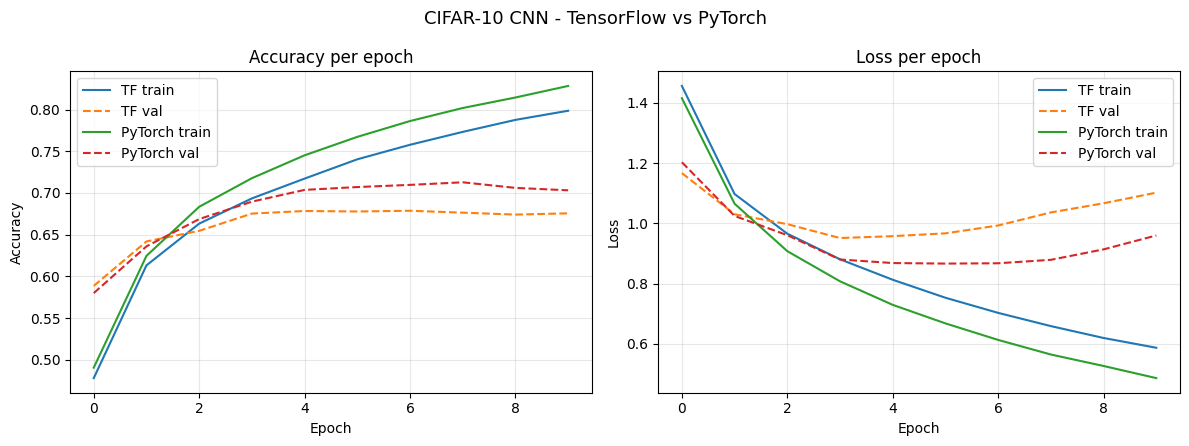

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.plot(h['tf_train_acc'], label='TF train')
ax.plot(h['tf_val_acc'],   label='TF val',   linestyle='--')
ax.plot(h['pt_train_acc'], label='PyTorch train')
ax.plot(h['pt_val_acc'],   label='PyTorch val', linestyle='--')
ax.set_title('Accuracy per epoch')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(h['tf_train_loss'], label='TF train')
ax.plot(h['tf_val_loss'],   label='TF val',   linestyle='--')
ax.plot(h['pt_train_loss'], label='PyTorch train')
ax.plot(h['pt_val_loss'],   label='PyTorch val', linestyle='--')
ax.set_title('Loss per epoch')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('CIFAR-10 CNN - TensorFlow vs PyTorch', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Takeaways

**Accuracy.** Both frameworks land in roughly the same place - the architecture is the dominant variable, not the framework. Small differences come from the preprocessing range (`[0, 1]` for TF vs `[-1, 1]` for PyTorch) and Adam's initial moments interacting with the random weight init.

**Lines of code.** TensorFlow wins on brevity for the standard happy path. `model.compile(...).fit(...).evaluate(...)` is the entire training pipeline. PyTorch makes you write the loop, but you get control over every step in exchange.

**Debugging.** PyTorch is easier to step through - the forward pass is real Python, you can print intermediate tensors, you can set a breakpoint inside `forward()` and inspect shapes. TensorFlow's `tf.function` traces things into a graph for speed, which is great for production but obscures the per-batch detail.

**My pick.** TF/Keras for a quick baseline or a standard classification job. PyTorch when the model is non-standard or I expect to spend time figuring out what's going wrong - which on anything beyond a tutorial is most of the time.

The full prose comparison is in [`REPORT.md`](REPORT.md).